# Brightfield Reconstruction with Experimental Background

This notebook is a **concise, code-focused companion** to the  
[**Base Brightfield Notebook (Gaussian Blobs)**](./1.Brightfield_base_notebook.ipynb).  
Here, we reuse the same tomographic reconstruction pipeline but add a **measured experimental background**  
to the simulated projections to test reconstruction robustness under non-ideal illumination.

We start from the same **Gaussian blob volume** used in the base notebook and overlay it with a  
**coverslip-like background** loaded from `test_data/glass_coverslip.npy`,  
which mimics uneven illumination and optical artifacts often seen in real microscopy data.

As before, a **Brightfield imaging model** generates forward projections under oscillatory rotation,  
and the **gradient-based optimization** reconstructs both the 3D volume and rotation parameters.  
This notebook focuses on demonstrating the workflow and assessing robustness,  
while detailed theoretical explanations can be found in the base notebook.

---

### Notebook Outline

1. **Load the 3D Volume**  
   Import the 3D data.

2. **Load and Visualize the Experimental Background**  
   Import `test_data/glass_coverslip.npy` and inspect the illumination pattern.

3. **Set Up Brightfield Imaging Model**  
   Configure the optical parameters for forward projections.

4. **Generate Projections**  
   Simulate 2D Brightfield projections and add the background pattern.

5. **Reconstruct the 3D Volume**  
   Run the tomographic optimization to refine both the volume and rotation parameters.

6. **Evaluate & Visualize**  
   Compare reconstructed slices and projections to the background-affected ground truth.

7. **Save Results**  
   Export the reconstructed volume and quaternions for further analysis.

> **Note:** This notebook mirrors the base pipeline but includes an experimental background overlay,  
> enabling direct comparison of reconstruction quality under realistic imaging conditions.



[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SkariZ/TomoDpDt/blob/main/Notebooks/sum_projection_vobble.ipynb)



In [1]:
# Uncomment if you run this notebook in Google Colab
#!pip install deeplay deeptrack plotly scipy opencv-python
#!git clone https://github.com/SkariZ/TomoDpDt.git
#import sys
#sys.path.append('/content/TomoDpDt')

In [2]:
# Uncomment if running this notebook locally
#import sys
#sys.path.append('..')

In [3]:
import sys
sys.path.append('..')

import tomodpdt

import numpy as np
import time
import random

import deeplay as dl
import torch
from torch.utils.data import DataLoader

In [4]:
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEV)

[suppressed training logs: 19 chars]


## 1. Load 3D Volume

In [5]:
volume = np.load('../test_data/vol_potato1.npy')

In [6]:
print(f"Shape of the volume: {volume.shape}")

Shape of the volume: (64, 64, 64)


The volume has refractive index values in the range 1.33-1.42.

In [7]:
volume.max(), volume.min(), volume.mean(), volume.std()

(1.4200001, 1.33, 1.3315866, 0.0052548475)

For optimization purposes it easier to work with the refractive index difference, assuming the sample is in water we can subtract 1.33.

In [8]:
volume = volume - 1.33

The 3D volume is stored in a `numpy` array and can be interactively visualized using the `ipyvolume` library together with `plotly`. Having it interactive and saving the `.ipynb` however make the file extremely large. Uncomment the code below for interactive plot.

In [9]:
# tomodpdt.plotting.visualize_3d_volume(volume)

Using sum projections along the x, y, and z axes, we can visualize the structure of the volume.

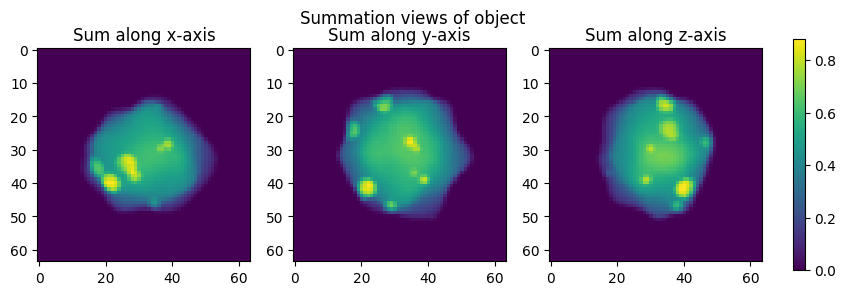

In [10]:
tomodpdt.plotting.plot_sum_object(volume)

## 2. Load and Visualize the Experimental Background

In this step, we load an experimentally captured **background intensity field**, such as one measured from a **glass coverslip** or **empty sample region**.  
This background provides a more realistic illumination and noise profile, allowing us to simulate experimental imaging conditions more accurately.

In [11]:
fields = np.load('../test_data/glass_coverslip.npy')
print(f"Shape of the fields: {fields.shape}")

Shape of the fields: (8, 282697)


The data is stored in a compressed fft-format, and has to be loaded...

In [12]:
fields = tomodpdt.vec_to_field_multi(fields, pupil_radius=300, shape=(1200, 1200))

We define a function to correct the field by removing the global phase offset...

In [13]:
def correctfield(field, n_iter=5):
    """
    Correct field by removing global phase offset using median phase estimation.
    """
    if field.dtype == torch.float32:
        field = field.to(torch.complex64)

    f_new = field.clone()
    f_new = f_new / torch.mean(torch.abs(f_new))  # normalize amplitude

    for _ in range(n_iter):
        f_new = f_new * torch.exp(-1j * torch.median(torch.angle(f_new)))

    return f_new

### 2.1 Visualize some of the experimental backgrounds.

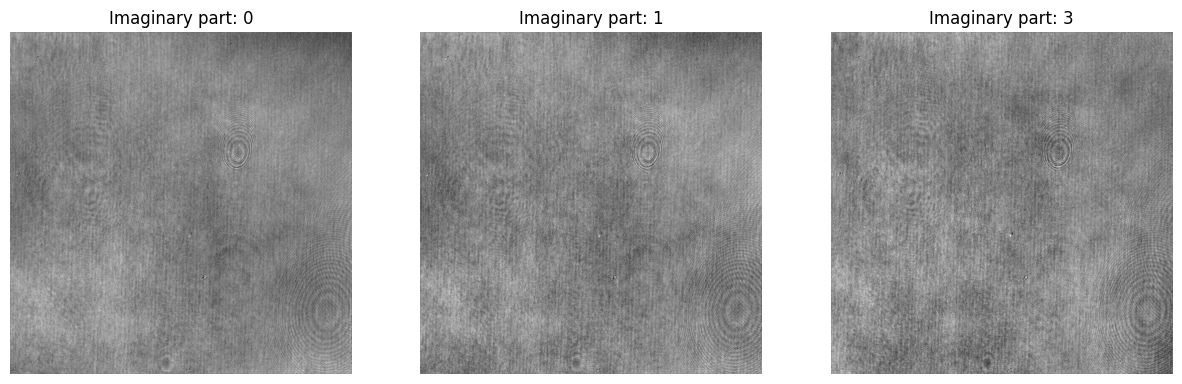

In [14]:
import matplotlib.pyplot as plt

### 2.1 Visualize some of the experimental backgrounds.
n_visualize = 3
fig, axs = plt.subplots(1, n_visualize, figsize=(15, 5))
rand_idx = np.random.permutation(fields.shape[0])[:n_visualize]
for i in range(n_visualize):
    axs[i].imshow(np.imag(fields[rand_idx[i]]), cmap='gray')
    axs[i].set_title(f'Imaginary part: {rand_idx[i]}')
    axs[i].axis('off')

## 3. Set Up Brightfield Imaging Model

In [15]:
from tomodpdt.imaging_modality_torch import setup_optics, imaging_model

# --- Setup the optical system ---
optics_settings = setup_optics(
    shape=volume.shape,       # Shape of the 3D volume
    padding_xy=volume.shape[0]//2,  # Padding in the lateral directions (avoids wrap-around effects)
    microscopy_regime='Brightfield', # Choose microscopy type: 'Brightfield', 'Fluorescence', etc.
    NA=1.1,                      # Numerical Aperture of the objective
    wavelength=520e-9,           # Illumination wavelength in meters
    resolution=200e-9,           # Effective pixel resolution in meters
    magnification=1,             # System magnification
    return_field=True            # Return the complex optical field instead of intensity only
)

# --- Build the imaging model ---
brightfield_model = imaging_model(optics_setup=optics_settings)


## 4. Generate Projections

In [16]:
test_object, q_gt, projections, imaging_model = tomodpdt.simulate.create_data(
    volume=volume, # The volume we want to reconstruct
    image_modality=brightfield_model, # We use our brightfield imaging model
    rotation_case='smooth_varying_random', # Smoothly varying random rotations
    samples=200, # Number of projections to simulate
    duration=1 #Number of full rotations (here: 1 full rotation
    )

[suppressed training logs: 20 chars]


### 4.1 Adding the experimental background

We create a function to add experimental backgrounds to the projections

In [17]:
def add_random_background_crops(
    projections,
    fields,
    correctfield_fn=correctfield,
    device="cpu",
    n_iter_field=3,
    field_scale=0.1,
    threshold=None,
    seed=None,
    return_backgrounds=False,
):
    """
    Add random background crops from experimental complex fields onto projection frames,
    while preserving the full complex field (real + imaginary parts).

    Parameters
    ----------
    projections : torch.Tensor
        Complex or two-channel tensor of shape (N, 2, H, W) or (N, H, W),
        representing simulated projections.
    fields : torch.Tensor
        Tensor of shape (M, Hf, Wf), which can be real or complex-valued
        experimental background fields.
    correctfield_fn : callable
        Function to correct field distortions (default = `correctfield`).
    device : str, optional
        Device for computation ('cpu' or 'cuda').
    n_iter_field : int, optional
        Number of correction iterations for field correction.
    field_scale : float, optional
        Scaling factor applied to the added background intensity.
    threshold : float, optional
        If provided, sets all field magnitude values below this threshold to zero.
    seed : int, optional
        Random seed for reproducibility.
    return_backgrounds : bool, optional
        If True, also return the cropped/processed background patches used.

    Returns
    -------
    torch.Tensor
        Modified projections with background overlays (complex-valued).
    (optional) torch.Tensor
        The cropped background fields applied to each projection.
    """

    if seed is not None:
        random.seed(seed)
        torch.manual_seed(seed)

    projections = projections.clone().to(device)
    bg_used = []

    for i in range(projections.shape[0]):
        # --- 1. Select a random background field ---
        rand_idx = random.randint(0, fields.shape[0] - 1)
        field_bg = fields[rand_idx].to(device)

        # --- 2. Random crop matching projection size ---
        H, W = projections.shape[-2:]
        x_start = random.randint(0, field_bg.shape[0] - H)
        y_start = random.randint(0, field_bg.shape[1] - W)
        field_crop = field_bg[x_start : x_start + H, y_start : y_start + W]

        # --- 3. Ensure complex type for background ---
        if not torch.is_complex(field_crop):
            field_crop = torch.complex(field_crop, torch.zeros_like(field_crop))

        # --- 4. Apply magnitude threshold if provided ---
        if threshold is not None:
            mask = torch.abs(field_crop) < threshold
            field_crop[mask] = 0.0

        # --- 5. Correct the background field ---
        field_crop = correctfield_fn(field_crop, n_iter=n_iter_field) * field_scale

        # --- 6. Prepare the projection field as complex ---
        proj = projections[i]
        if not torch.is_complex(proj):
            proj_field = torch.complex(proj[0], proj[1])
        else:
            proj_field = proj

        proj_field = correctfield_fn(proj_field, n_iter=n_iter_field)

        # --- 7. Combine projection + background (complex addition) ---
        combined_field = proj_field + field_crop

        combined_field = correctfield_fn(combined_field, n_iter=n_iter_field)

        projections[i, 0] = torch.real(combined_field)
        projections[i, 1] = torch.imag(combined_field) 

        # --- 8. Optionally store background used ---
        if return_backgrounds:
            bg_used.append(field_crop.detach().cpu())

    # --- 9. Return projections and optionally backgrounds ---
    if return_backgrounds:
        return projections, torch.stack(bg_used)

    return projections


Add experimental backgrounds to the projections... 

In [18]:
projections = add_random_background_crops(projections, fields, field_scale=0.1, device=DEV)

### 4.2 Visualizing the Training Data

In this section, we explore the generated training data through the forward images and the corresponding rotation parameters.

#### Vizualising the forward projections

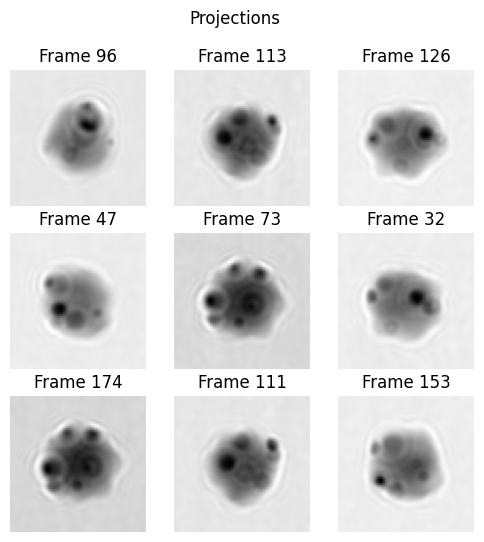

In [19]:
tomodpdt.plotting.plot_grid33_frames(projections, title="Projections", randomize=True)

#### Visualizing the Quaternion Trajectory

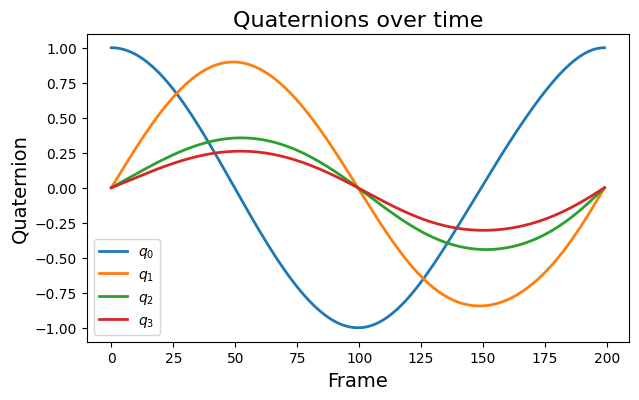

In [20]:
tomodpdt.plotting.plot_quaternions(q_gt)

## 4. Reconstruct the 3D Volume

In this section, we focus on **tomographic reconstruction**, that is, the process of recovering a 3D volume from a set of 2D projection images acquired under different viewing angles.

#### Create the tomographic model

In [21]:
tomographic_model = tomodpdt.Tomography(
    volume_size=volume.shape, # The size of the volume
    initial_volume='zeros', # 'refraction' since we are optimizing the refractive index
    rotation_optim_case='quaternion', # 'basis' or 'quaternion', 'basis' is smoother
    imaging_model=brightfield_model, # The imaging model
    )

#### Initialize the parameters

In [22]:
tomographic_model.initialize_parameters(projections, normalize=False, max_epochs=200)

c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


[suppressed training logs: 225 chars]


[suppressed training logs: 740 chars]
c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\core\module.py:512: You called `self.log('train_KL', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


[suppressed training logs: 225 chars]


✅ Rotation initialization from latent space successful.


For vizualisation we initialize a `TomoPlotter` class for easier plotting.

In [23]:
plotter = tomodpdt.plotting.TomoPlotter(tomographic_model)

#### Visualizing the Latent Space Trajectory, Peaks and the Initial Guess


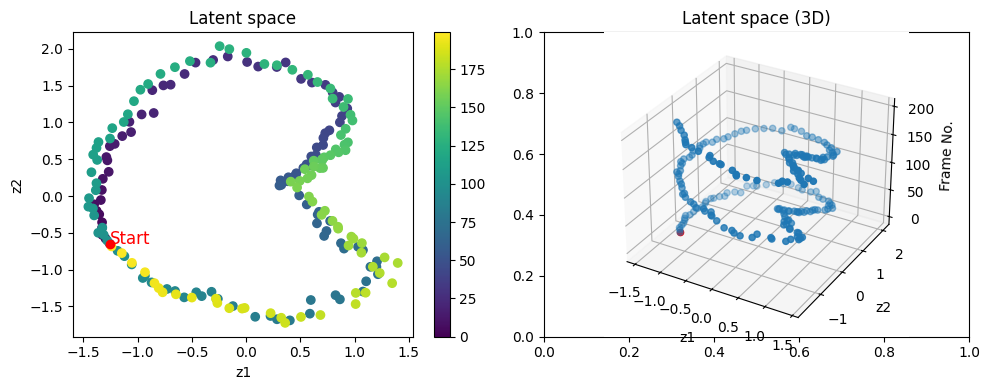

In [24]:
plotter.plot_latent_space()

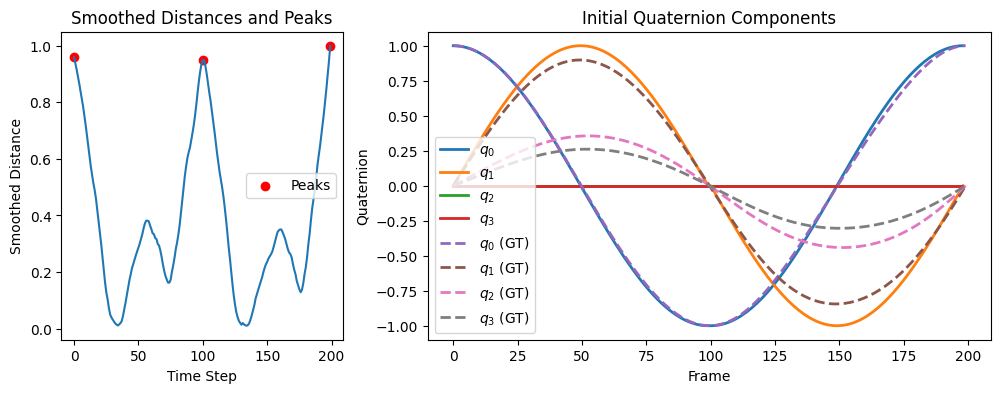

In [25]:
plotter.plot_smooth_dist_intial_guess(q_gt=q_gt)

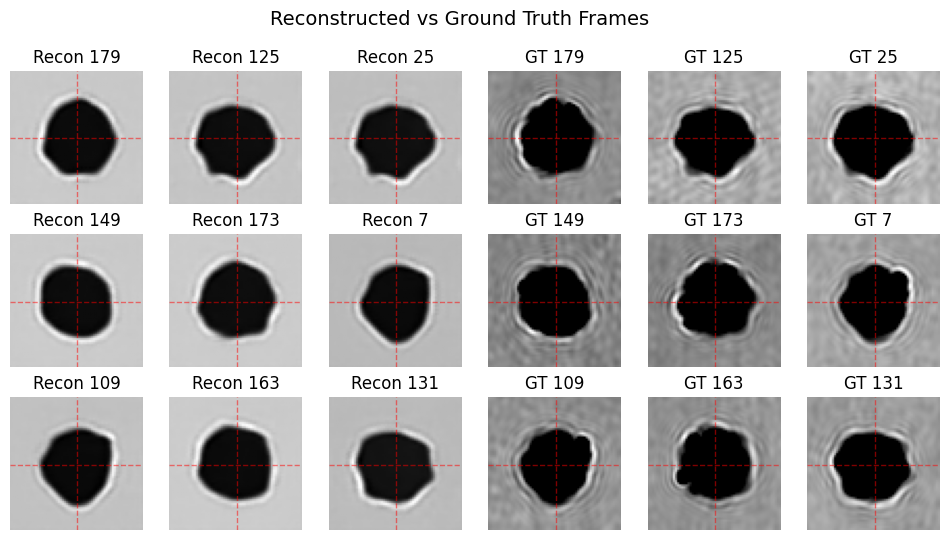

In [26]:
plotter.plot_reconstructed_vs_gt()


### 4.1 Start the 3D Reconstruction Optimization


In [27]:
N1 = len(tomographic_model.frames) # Number of frames
idx = torch.arange(N1) # List of indexes
epochs_object_only = 50 # Number of epochs for the object only optimization
batch_size_object_only = 32 # Batch size for the object only optimization

In [28]:
# Toggle the gradients of the quaternion parameters to False
tomographic_model.toggle_gradients_quaternion(False)

# Toggle the gradients of the translation parameters to False
tomographic_model.toggle_gradients_translation(False)

# Move the model to device and all parameters
tomographic_model.move_all_to_device(DEV)

[suppressed training logs: 1,472 chars]
-----------------------------------------------------------------
-----------------------------------------------------------------
262 K     Trainable params
357 K     Non-trainable params
619 K     Total params
2.478     Total estimated model params size (MB)
5         Modules in train mode
78        Modules in eval mode


[suppressed training logs: 294 chars]


[suppressed training logs: 225 chars]


[suppressed training logs: 45 chars]


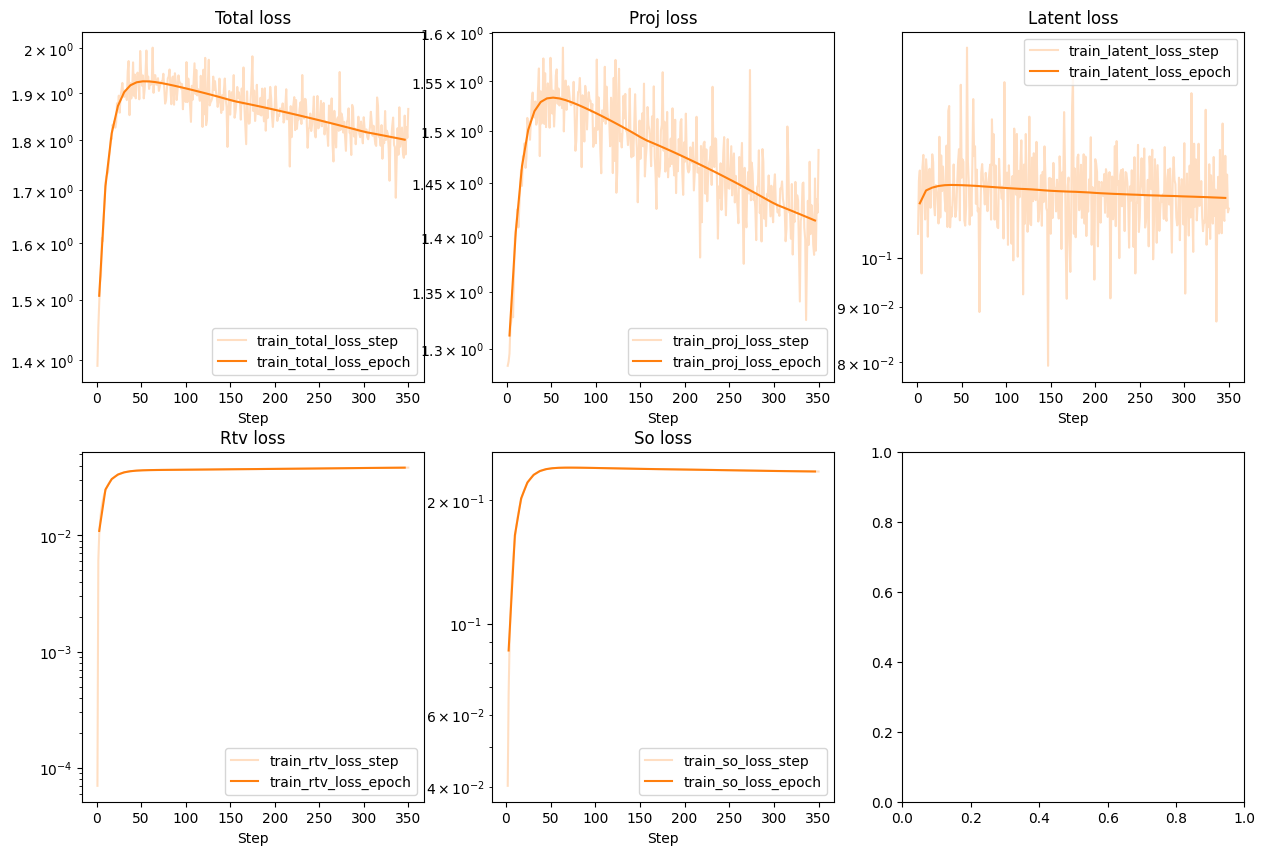

In [29]:
# Train the model
start_time = time.time()
trainer = dl.Trainer(max_epochs=epochs_object_only, accelerator="auto", log_every_n_steps=10)
trainer.fit(tomographic_model, DataLoader(idx, batch_size=batch_size_object_only , shuffle=True))
print("Training time: ", (time.time() - start_time) / 60, " minutes")

# Plot the training history
try:
    trainer.history.plot()
except:
    print("No history to plot...")

### 4.2 Optimize the 3D volume and the rotation parameters

In [30]:
epochs_object_rot = 500 # Number of epochs for the object and rotation optimization
batch_size_object_rot = 32 # Batch size for the object and rotation optimization

In [31]:
# Toggle the gradients of the quaternion parameters
tomographic_model.toggle_gradients_quaternion(True)

# The gradients of the translation parameters are already False and remain so since we do not want to optimize them now
# tomographic_model.toggle_gradients_translation(False)

# Move the model to device
tomographic_model.move_all_to_device(DEV)

and train the model for `epochs_object_rot` epochs...

[suppressed training logs: 926 chars]
-----------------------------------------------------------------
-----------------------------------------------------------------
262 K     Trainable params
356 K     Non-trainable params
619 K     Total params
2.478     Total estimated model params size (MB)
5         Modules in train mode
78        Modules in eval mode


[suppressed training logs: 294 chars]


[suppressed training logs: 225 chars]


[suppressed training logs: 45 chars]


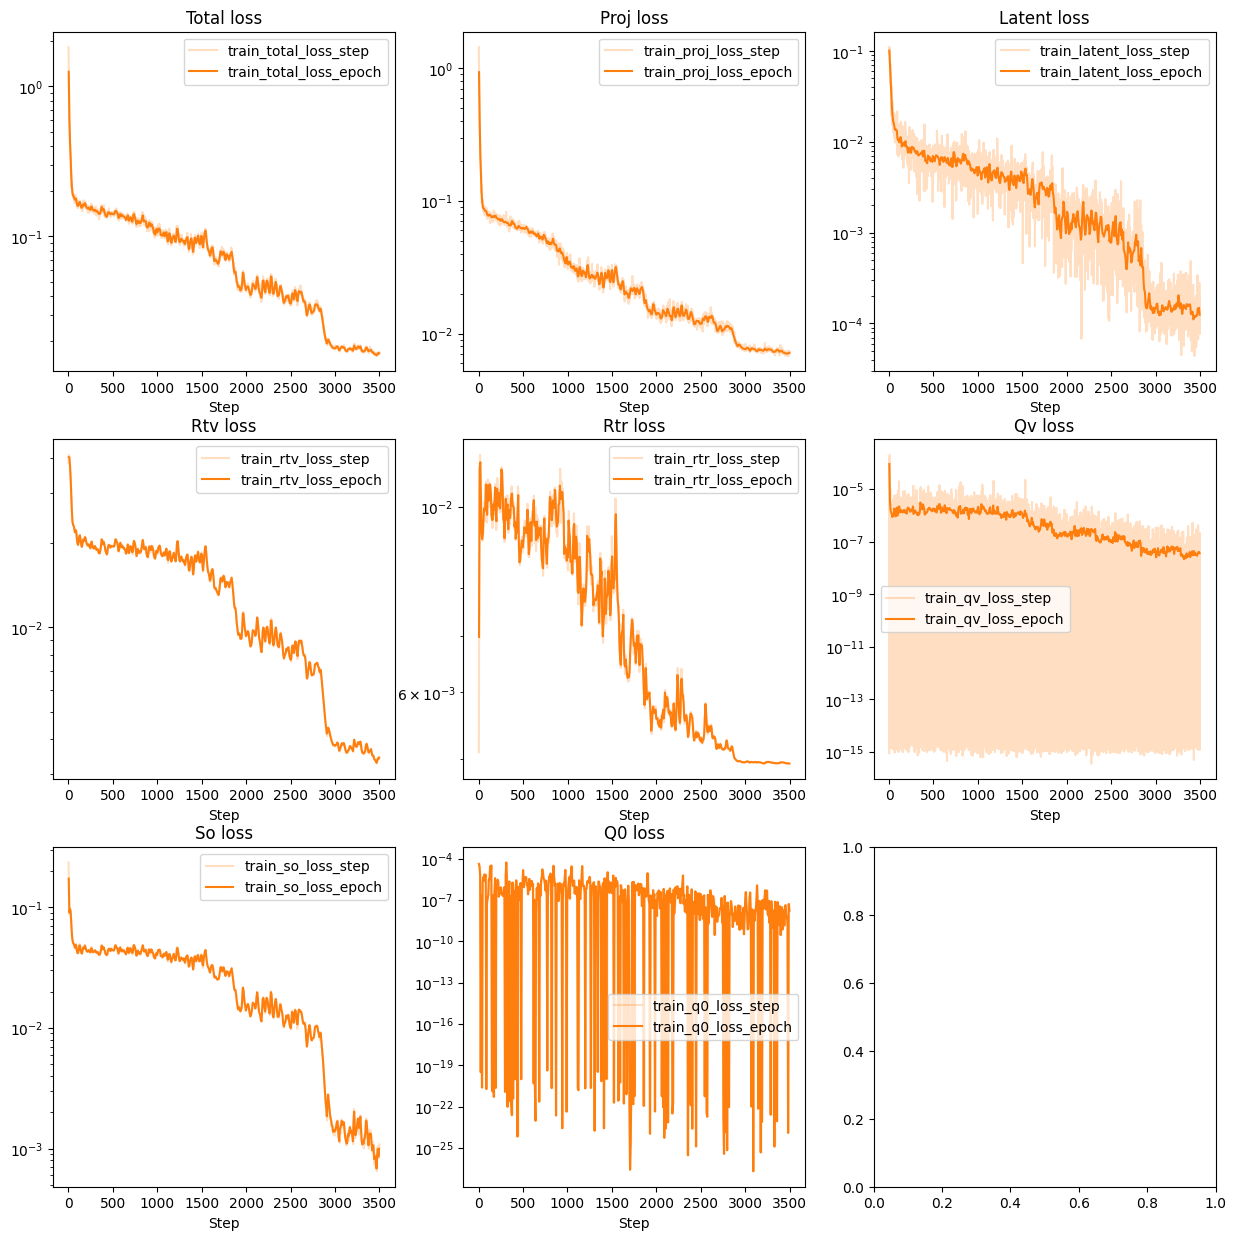

In [32]:
# Train the model
start_time = time.time()
trainer = dl.Trainer(max_epochs=epochs_object_rot, accelerator="auto", log_every_n_steps=None)
trainer.fit(tomographic_model, DataLoader(idx, batch_size=batch_size_object_rot , shuffle=True))
print("Training time: ", (time.time() - start_time) / 60, " minutes")

# Plot the training history
try:
    trainer.history.plot()
except:
    print("No history to plot...")

## 6.  Evaluate & Visualize

In [33]:
# Move it to the GPU if possible for faster plotting
tomographic_model.move_all_to_device(DEV)

# Visualize the final volume and rotations.
plotter = tomodpdt.plotting.TomoPlotter(tomographic_model)

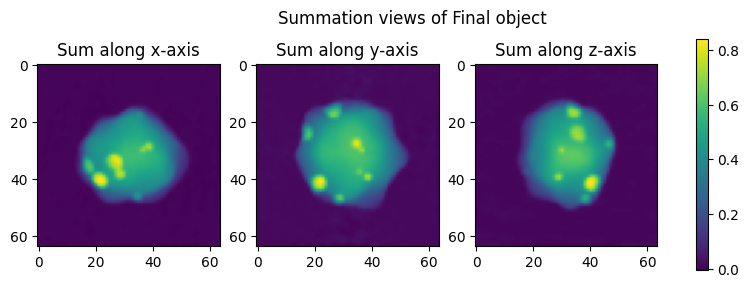

In [34]:
plotter.plot_sum_object(save_name="Final object")

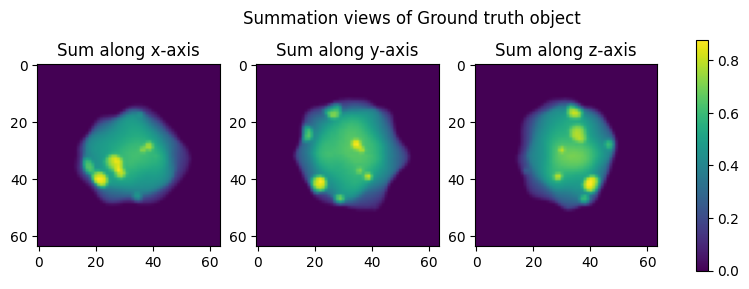

In [35]:
plotter.plot_sum_object(obj=test_object.cpu(), save_name="Ground truth object")

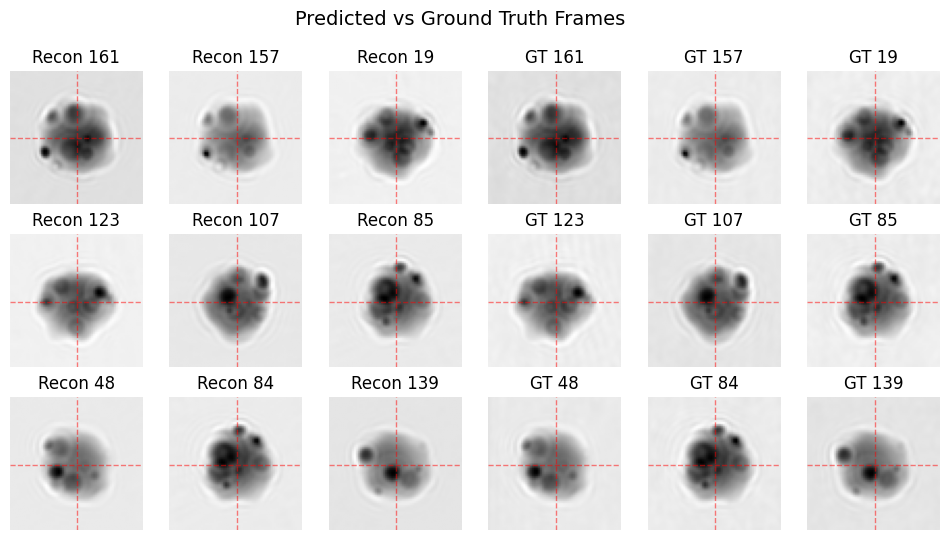

In [36]:
plotter.plot_reconstructed_vs_gt(column_headers=["Predicted", "Ground Truth"], forward=True, save_name="Reconstructed vs GT")

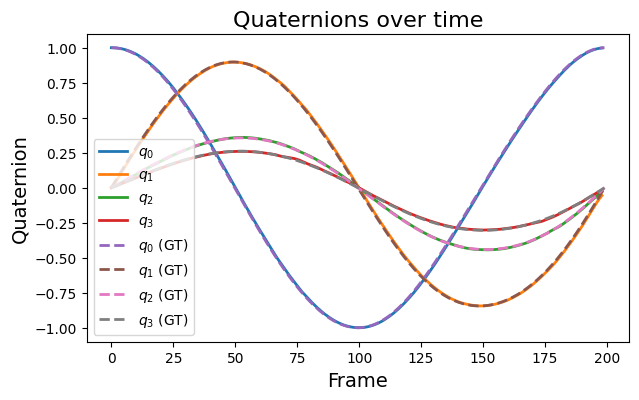

In [37]:
plotter.plot_quaternions(q_gt=q_gt)

The most effective way to visualize and compare the reconstructed volume to the ground truth is through interactive 3D plots using `plotly`.

In [38]:
# Uncomment belowto visualize the 3D volume
# tomodpdt.plotting.visualize_3d_volume(tomographic_model.volume.detach().cpu(), save_name="Final object 3D")
# tomodpdt.plotting.visualize_3d_volume(test_object.cpu(), save_name="Ground truth object 3D")

## 7. Save Result

Once the process is complete, we can save the reconstructed volume and the quaternion parameters to `numpy` arrays.

In [39]:
# Define where to save the reconstruction results
# save_folder = "path/to/save/folder"

# --- Save the reconstructed 3D volume ---
# Extract the optimized volume from the model and save as a NumPy array
# volume = tomographic_model.get_volume().detach().cpu().numpy()
# np.save(f"{save_folder}/volume.npy", volume)

# --- Save the optimized quaternions ---
# Extract the final quaternion parameters and save them as a NumPy array
# quaternions_pred = tomographic_model.get_quaternions_final().detach().cpu().numpy()
# np.save(f"{save_folder}/quaternions.npy", quaternions_pred)

